In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

GENERATED_DIR = Path.cwd() / "generated"

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-qd6zhv5y because the default path (/.config/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
DURATION_DIR = GENERATED_DIR / "duration"
LINGUISTIC_DIR = GENERATED_DIR / "linguistic"

In [3]:
DATA_SIZE = 4000

duration_paths = sorted(DURATION_DIR.glob("*"))[:DATA_SIZE] # Remove mean.npy and std.npy
linguistic_paths = sorted(LINGUISTIC_DIR.glob("*"))[:DATA_SIZE]
len(duration_paths), len(linguistic_paths)

(4000, 4000)

In [4]:
duration_arrays = [np.load(path) for path in duration_paths]
linguistic_arrays = [np.load(path) for path in linguistic_paths]

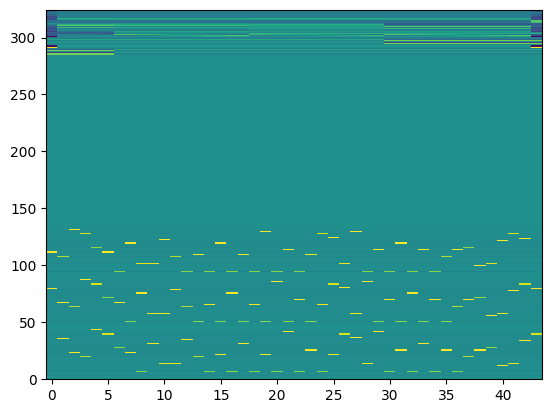

In [5]:
plt.imshow(linguistic_arrays[0].T, origin='lower', aspect='auto', interpolation='nearest')
plt.clim(-4, +4)

In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64,),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dense(64,),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dense(64,),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dense(1, activation=None),
])

2022-10-16 08:04:28.254534: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:991] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-10-16 08:04:28.258149: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:991] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-10-16 08:04:28.258312: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:991] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-10-16 08:04:28.259144: I tensorflow/core/platform/cpu_feature_guard.cc:194] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE3 SSE4.1 SSE4.2 AVX
To enable them in other operations, rebuild TensorFlow with the appropriate 

In [7]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              loss=tf.keras.losses.MeanSquaredError(),
              metrics=['MAE'])

In [9]:
BATCH_SIZE = 2 ** 13

dataset = tf.data.Dataset.from_tensor_slices(
    (np.concatenate(linguistic_arrays, axis=0), np.concatenate(duration_arrays, axis=0))
).shuffle(BATCH_SIZE * 10).batch(BATCH_SIZE)
model.fit(dataset, epochs=100)

Epoch 1/100
31/31 [==============================] - 1s 26ms/step - loss: 0.3346 - MAE: 0.2717
Epoch 2/100
31/31 [==============================] - 1s 25ms/step - loss: 0.3371 - MAE: 0.2722
Epoch 3/100
31/31 [==============================] - 1s 24ms/step - loss: 0.3344 - MAE: 0.2695
Epoch 4/100
31/31 [==============================] - 1s 24ms/step - loss: 0.3357 - MAE: 0.2708
Epoch 5/100
31/31 [==============================] - 1s 25ms/step - loss: 0.3358 - MAE: 0.2706
Epoch 6/100
31/31 [==============================] - 1s 24ms/step - loss: 0.3340 - MAE: 0.2702
Epoch 7/100
31/31 [==============================] - 1s 25ms/step - loss: 0.3403 - MAE: 0.2732
Epoch 8/100
31/31 [==============================] - 1s 24ms/step - loss: 0.3360 - MAE: 0.2716
Epoch 9/100
31/31 [==============================] - 1s 25ms/step - loss: 0.3435 - MAE: 0.2757
Epoch 10/100
31/31 [==============================] - 1s 24ms/step - loss: 0.3355 - MAE: 0.2700
Epoch 11/100
31/31 [=============================

31/31 [==============================] - 1s 24ms/step - loss: 0.3318 - MAE: 0.2740
Epoch 87/100
31/31 [==============================] - 1s 24ms/step - loss: 0.3282 - MAE: 0.2704
Epoch 88/100
31/31 [==============================] - 1s 24ms/step - loss: 0.3278 - MAE: 0.2689
Epoch 89/100
31/31 [==============================] - 1s 24ms/step - loss: 0.3285 - MAE: 0.2687
Epoch 90/100
31/31 [==============================] - 1s 25ms/step - loss: 0.3334 - MAE: 0.2709
Epoch 91/100
31/31 [==============================] - 1s 25ms/step - loss: 0.3333 - MAE: 0.2702
Epoch 92/100
31/31 [==============================] - 1s 24ms/step - loss: 0.3324 - MAE: 0.2691
Epoch 93/100
31/31 [==============================] - 1s 24ms/step - loss: 0.3310 - MAE: 0.2690
Epoch 94/100
31/31 [==============================] - 1s 24ms/step - loss: 0.3313 - MAE: 0.2710
Epoch 95/100
31/31 [==============================] - 1s 25ms/step - loss: 0.3286 - MAE: 0.2697
Epoch 96/100
31/31 [==============================] -

2/2 [==============================] - 0s 2ms/step


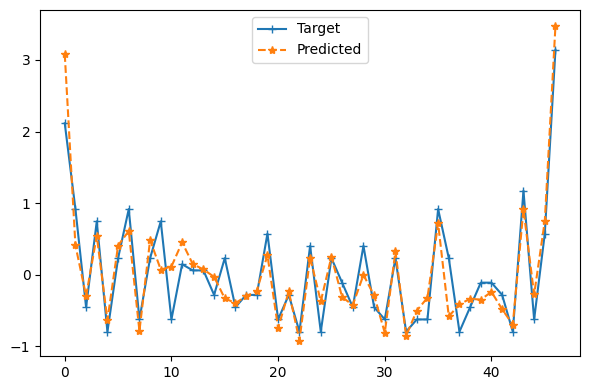

In [10]:
i = 4

fig, ax = plt.subplots(1,1, figsize=(6,4))
ax.plot(duration_arrays[i], "-+", label="Target")
ax.plot(model.predict(linguistic_arrays[i]), "--*", label="Predicted")


"""
ax.set_xticks(np.arange(len(test_phonemes)))
ax.set_xticklabels(test_phonemes)
ax.set_xlabel("Phoneme")
ax.set_ylabel("Duration (the number of frames)")
"""
ax.legend()

plt.tight_layout()

In [11]:
model.save("duration_model.h5")